In [ ]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.utils.utility import standardizer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

TypeError: DataPipeline.__init__() missing 1 required positional argument: 'config'

# Arquivos

In [ ]:
dados_brutos = pd.read_excel(r"C:\_Master\programacao\Guilherme-Betta\IC2\data\in\dadosBrutos.xlsx")

dados_brutos_pivot = pd.read_excel(r"C:\_Master\programacao\Guilherme-Betta\IC2\data\in\dadosBrutosProntos.xlsx")

dados_limpos = pd.read_excel(r"C:\_Master\programacao\Guilherme-Betta\IC2\data\in\limpeza.xlsx")

imput_knn = pd.read_excel(r"C:\_Master\programacao\Guilherme-Betta\IC2\data\out\knn.xlsx")

Organizando as colunas de cada base de dados em variaveis

In [ ]:
# dados_brutos

metadados_brutos = ['Data', 'Estatistica']
variaveis_brutos = [cols for cols in dados_brutos.columns if cols not in metadados_brutos]

# dados_brutos_prontos

metadados_brutos_pivot = ['Data', 'Estatistica', 'data_normalizada']
variaveis_brutos_pivot = [cols for cols in dados_brutos_pivot.columns if cols not in metadados_brutos_pivot]

# dados_limpos

## Após a limpeza, os dados não numéricos foram removidos das colunas com as variaveis de interesse,
## sendo possível implementar métodos mais flexíveis

variaveis_limpos = [coluna for coluna in dados_limpos.select_dtypes(include=float)] 
metadados_limpos = [coluna for coluna in dados_limpos.select_dtypes(exclude=float)]

# imput_knn

variaveis_knn = [coluna for coluna in imput_knn.select_dtypes(include=float)]
metadados_knn = [coluna for coluna in imput_knn.select_dtypes(exclude=float)]

# print(metadados_brutos, metadados_brutos_pivot, metadados_limpos, metadados_knn, variaveis_brutos, variaveis_brutos_pivot, variaveis_limpos, variaveis_knn)

['Data', 'Estatistica'] ['Data', 'Estatistica', 'data_normalizada'] ['Unnamed: 0', 'Data', 'data_normalizada'] ['Unnamed: 0.1', 'Unnamed: 0', 'Data', 'data_normalizada'] ['COR', 'TURB.', 'pH', 'ALC.', 'AC.', 'O.C.', 'DBO', 'O.D.', 'Cl', 'DUR.', 'Fe', 'Mn', 'N', 'P', 'Cond.', 'Amonia ', 'Surfact.', 'Cianobacteria', 'S.T.', 'C.T.', 'C.F.', 'Clorofila', 'F', 'Fenol'] ['COR_Max.', 'COR_Med.', 'COR_Min.', 'TURB._Max.', 'TURB._Med.', 'TURB._Min.', 'pH_Max.', 'pH_Med.', 'pH_Min.', 'ALC._Max.', 'ALC._Med.', 'ALC._Min.', 'AC._Max.', 'AC._Med.', 'AC._Min.', 'O.C._Max.', 'O.C._Med.', 'O.C._Min.', 'DBO_Max.', 'DBO_Med.', 'DBO_Min.', 'O.D._Max.', 'O.D._Med.', 'O.D._Min.', 'Cl_Max.', 'Cl_Med.', 'Cl_Min.', 'DUR._Max.', 'DUR._Med.', 'DUR._Min.', 'Fe_Max.', 'Fe_Med.', 'Fe_Min.', 'Mn_Max.', 'Mn_Med.', 'Mn_Min.', 'N_Max.', 'N_Med.', 'N_Min.', 'P_Max.', 'P_Med.', 'P_Min.', 'Cond._Max.', 'Cond._Med.', 'Cond._Min.', 'Amonia _Max.', 'Amonia _Med.', 'Amonia _Min.', 'Surfact._Max.', 'Surfact._Med.', 'Surfact._

# Boxplots

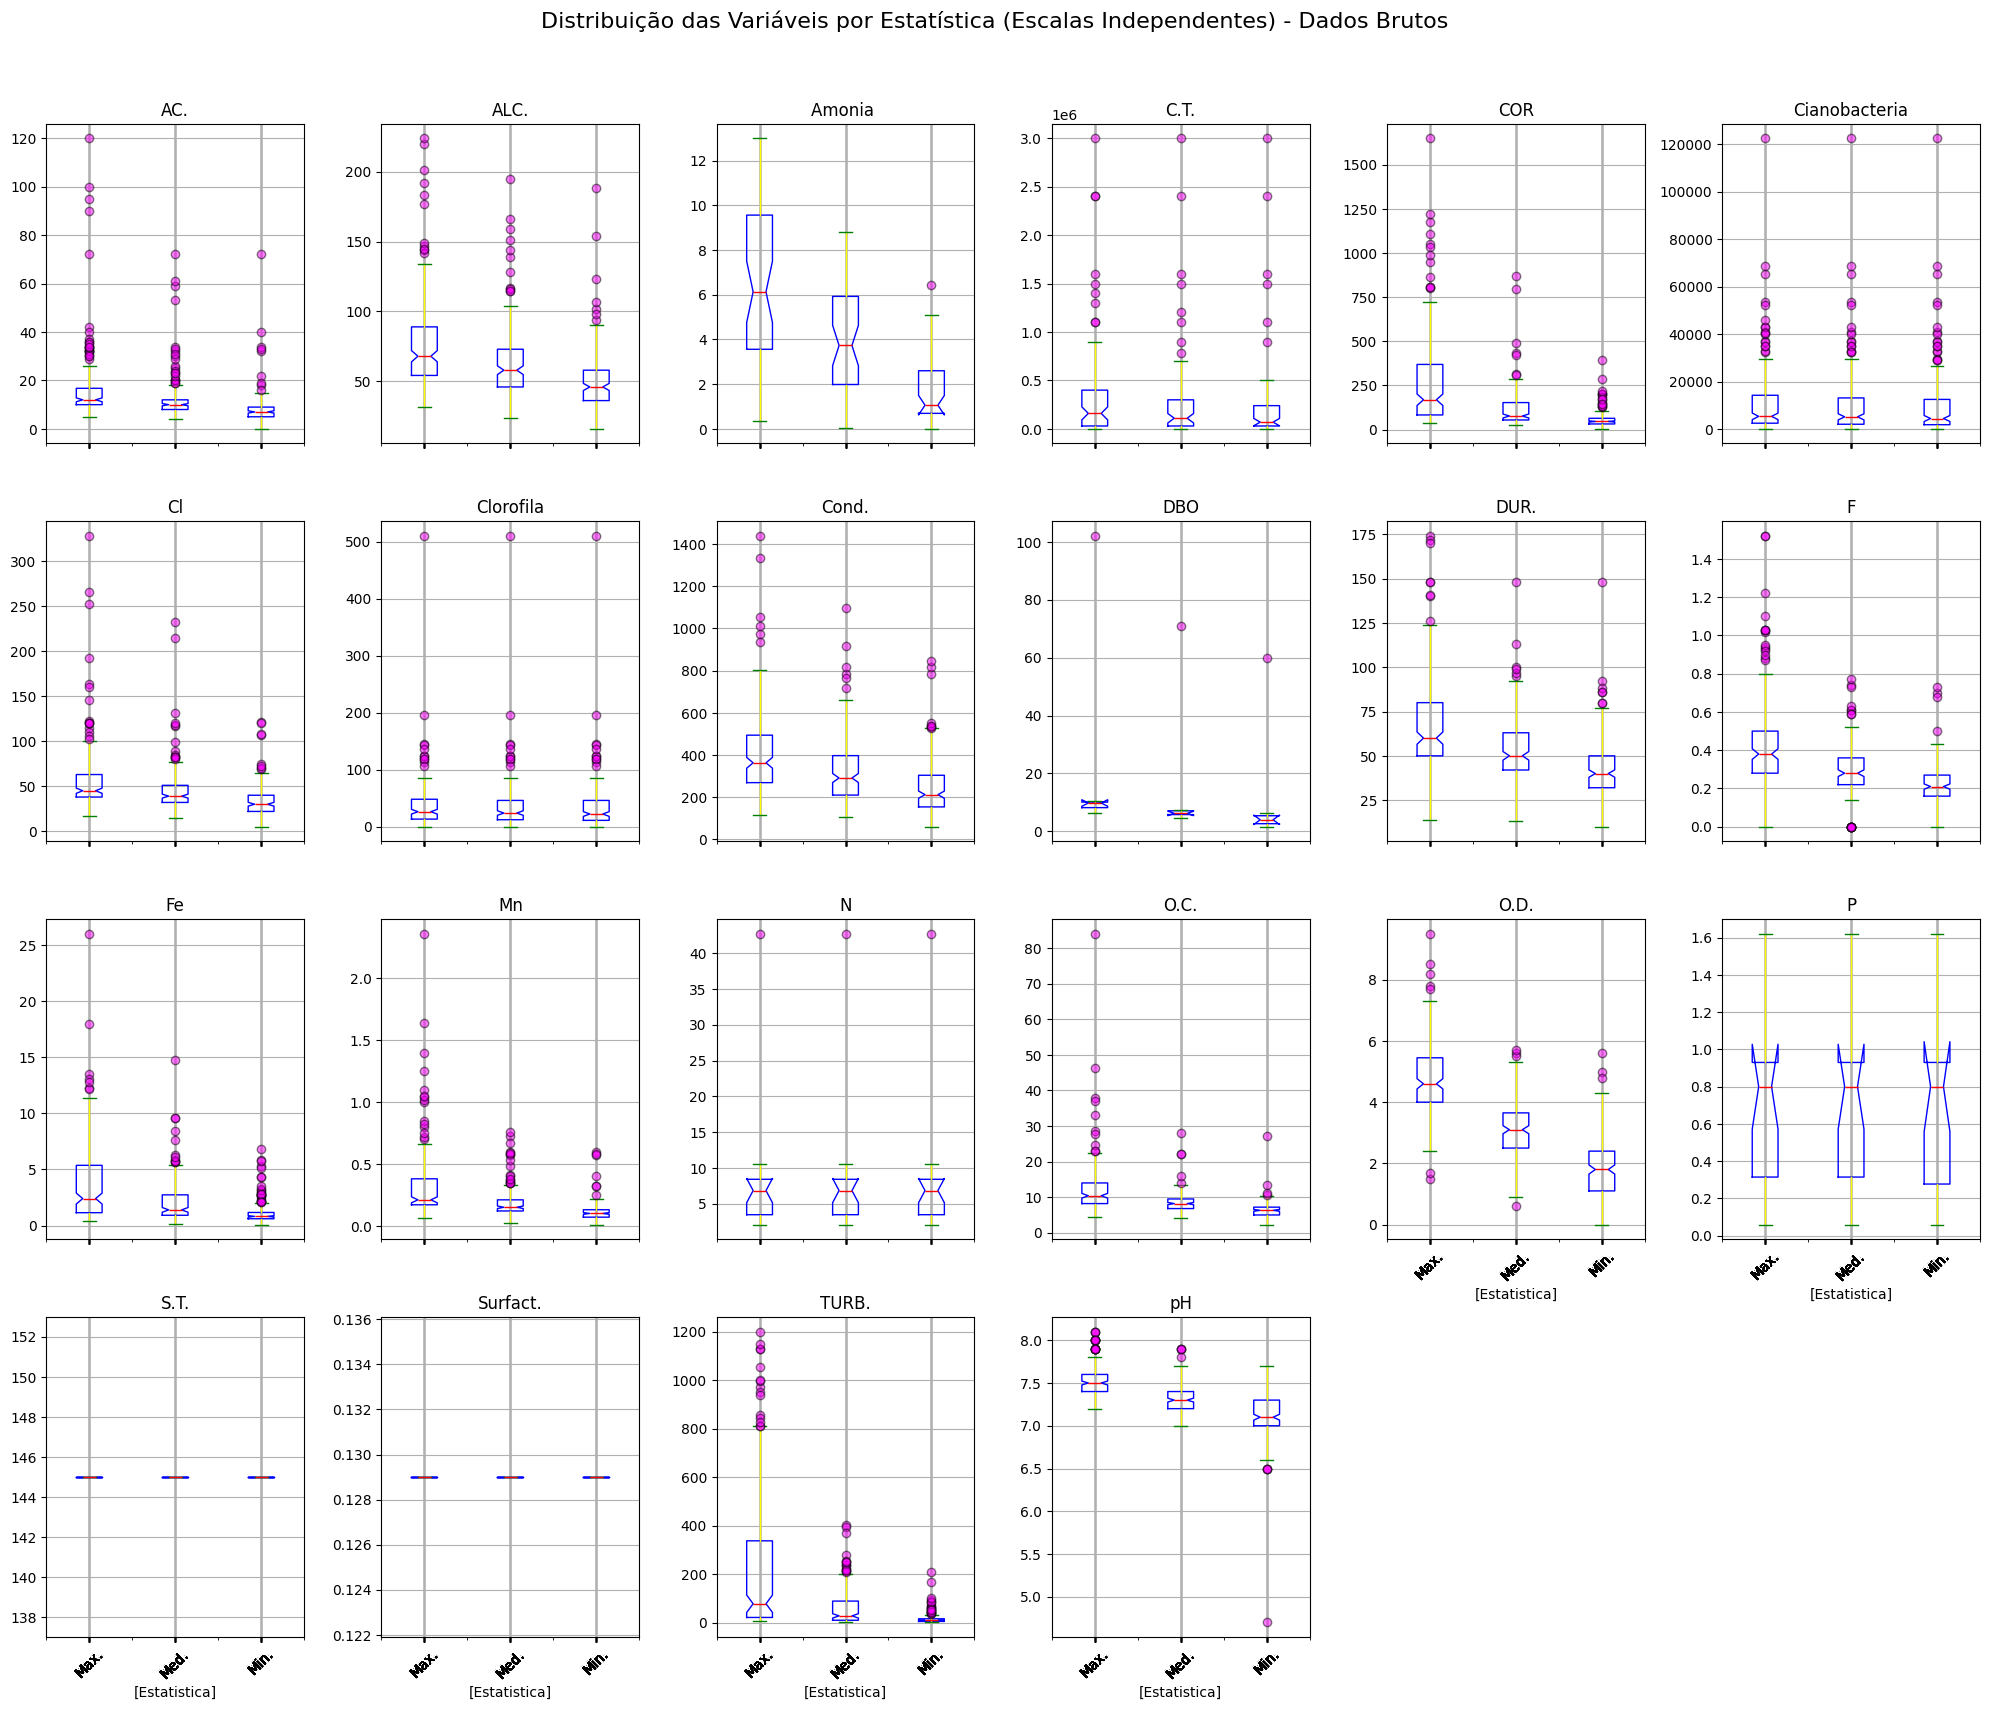

In [ ]:
### Formatação dos boxplots

cores_customizadas = {      # Guarda as cores para cada parte do boxplot num dicionário
    'boxes': 'Blue',
    'medians': 'Red',
    'whiskers': 'Yellow',
    'caps': 'Green'
}

estilo_outliers = dict(             # Determina a formatação dos pontos outliers
    markerfacecolor = 'magenta',    # Determina a cor dos pontos      
    marker = 'o',                   # Determina o formato dos pontos (no caso, círculos perfeitos)
    alpha = 0.5                     # Determina a opacidade / transparência dos pontos
)

def boxplot(df):
    if 'Estatistica' in

In [ ]:
dados.boxplot(by='Estatistica',             # Agrupa os dados por Estatística
            layout=(5, 6),                  # Organiza os boxplots em linhas e colunas
            figsize=(20,20),                # Determina o tamanho da figura
            sharey = False,                 # Faz com que diferentes variáveis apresentem diferentes escalas (mais apropriadas para cada uma)
            rot = 45,                       # Rotaciona os rótulos para evitar sobreposição
            color = cores_customizadas,     # Aplica as cores escolhidas
            flierprops = estilo_outliers,
            notch = True,
            )   # Aplica a formatação dos outliers escolhida
plt.suptitle('Distribuição das Variáveis por Estatística (Escalas Independentes)', fontsize=16, y=1.02)

# Ajusta o espaçamento entre os gráficos para não ficarem grudados
plt.tight_layout()

In [ ]:
### Criando variaveis contendo cada tipo de estatistica (Min, Med, Max)

cols_min = [coluna for coluna in dados_prontos.columns if coluna.endswith('Min.')] 

cols_med = [coluna for coluna in dados_prontos.columns if coluna.endswith('Med.')] 

cols_max = [coluna for coluna in dados_prontos.columns if coluna.endswith('Max.')]

In [ ]:
ax_min = dados_prontos[cols_min].plot(kind='box',
                                subplots=True,
                                layout=(6,8),
                                figsize=(20,20),
                                sharey=False,
                                color = cores_customizadas,
                                flierprops = estilo_outliers
                                )
plt.suptitle('Distribuição dos valores mínimos de cada variável (Escalas independentes)', fontsize = 16, y = 1.02)

plt.tight_layout()

In [ ]:
ax_med = dados_prontos[cols_med].plot(kind='box',
                                subplots=True,
                                layout=(6,8),
                                figsize=(20,20),
                                sharey=False,
                                color = cores_customizadas,
                                flierprops = estilo_outliers
                                )
plt.suptitle('Distribuição dos valores médios de cada variável (Escalas independentes)', fontsize = 16, y = 1.02)

plt.tight_layout()

In [ ]:
ax_max = dados_prontos[cols_max].plot(kind='box',
                                subplots=True,
                                layout=(6,8),
                                figsize=(20,20),
                                sharey=False,
                                color = cores_customizadas,
                                flierprops = estilo_outliers
                                )
plt.suptitle('Distribuição dos valores máximos de cada variável (Escalas independentes)', fontsize = 16, y = 1.02)

plt.tight_layout()

# Dados Faltantes

In [ ]:
colunas_data = [coluna for coluna in dados.columns if str(dados[coluna].dtype).startswith('datetime')]

print(colunas_data)

In [ ]:
msno.matrix(dados)  # Gera uma matriz representando dados faltantes/coluna

In [ ]:
msno.bar(dados) # Gera um gráfico de barras

In [ ]:
msno.heatmap(dados) # Gera um mapa de calor

In [ ]:
msno.dendrogram(dados)  # Gera um dendograma

In [ ]:
# taxa de missing por ano (0 → completo, 1 → tudo faltando)
missing_por_ano = (dados.drop(columns=colunas_data).groupby(dados["Data"].dt.year).apply(lambda x: x.isna().mean()*100))

# transpor para variáveis ficarem no eixo vertical
missing_por_ano = missing_por_ano.T

In [ ]:
plt.figure(figsize=(18, 10))
sns.heatmap(
    missing_por_ano,
    cmap="RdBu_r",  # azul = completo | vermelho = faltante
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="black"
)

plt.title("Taxa de dados faltantes (%) por variável e ano")
plt.xlabel("Ano")
plt.ylabel("Variável")
plt.show()

In [ ]:
missing_meses = (dados.drop(columns=colunas_data)).groupby(dados['Data'].dt.year).apply(lambda x: x.isna().sum())

missing_meses = missing_meses.T


In [ ]:
plt.figure(figsize=(18, 10))
sns.heatmap(
    missing_meses,
    cmap="RdBu_r",
    vmin=0,
    vmax=12,
    linewidths=0.5,
    linecolor="black",
    cbar_kws={"label": "Meses faltantes"}
)

plt.title("Meses faltantes por variável e ano")
plt.xlabel("Ano")
plt.ylabel("Variável")
plt.show()